# Modelado: Diseño Experimental 2×2

| | Config A (28 raw) | Config B (28 raw + 10 Schilit) |
|---|---|---|
| **XGBoost** | Exp. 1 | Exp. 2 |
| **RUSBoost** | Exp. 3 ⚑ | Exp. 4 |

 Checkpoint Bao: RUSBoost + Config A debe dar AUC ∈ [0.70, 0.74]
(Erratum Bao et al. 2022 tras corrección de fraude serial)

In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))
from features import RAW_28, SCHILIT_10
from preprocessing import split_temporal_with_serial_fraud, winsorize_and_impute
from model import train_xgboost, train_rusboost
from evaluation import evaluate_model, plot_roc_curves, plot_pr_curves

warnings.filterwarnings("ignore")

RESULTS_DIR = Path("../results/models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = Path("../figures/models")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargar dataset enriquecido (Día 2)
df = pd.read_csv("../data/data_with_schilit.csv", low_memory=False)
print(f"Dataset cargado: {df.shape}  (esperado: 146045 × 56)")
print(f"Columnas SCHILIT_10: {SCHILIT_10}")

Dataset cargado: (146045, 56)  (esperado: 146045 × 56)
Columnas SCHILIT_10: ['receivables_index', 'inventory_index', 'payables_index', 'accrual_ratio', 'soft_assets', 'dpi', 'gross_margin_index', 'sales_growth_index', 'leverage_index', 'asset_quality_index']


## Split temporal con tratamiento de fraude serial

In [2]:
print("=" * 60)
print("SPLIT TEMPORAL + TRATAMIENTO FRAUDE SERIAL")
print("=" * 60)

train, test = split_temporal_with_serial_fraud(df)

# Validaciones con assert
assert len(train) == 71748,             f"Train obs: esperado 71748, obtenido {len(train)}"
assert int(train["misstate"].sum()) == 410, f"Fraudes train: esperado 410, obtenido {int(train['misstate'].sum())}"
assert len(test)  == 35166,             f"Test obs: esperado 35166, obtenido {len(test)}"
assert int(test["misstate"].sum()) == 261,  f"Fraudes test: esperado 261, obtenido {int(test['misstate'].sum())}"
print("\nAserciones de validación: todas OK ✓")

prevalence_test = int(test["misstate"].sum()) / len(test)
print(f"Prevalencia en test: {prevalence_test:.4f}  ({int(test['misstate'].sum())}/{len(test)})")

SPLIT TEMPORAL + TRATAMIENTO FRAUDE SERIAL
Train (antes reset) :  71,748 obs  |   514 fraudes
Test                :  35,166 obs  |   261 fraudes

Observaciones de fraude reseteadas en train : 104
Train (después reset):  71,748 obs  |   410 fraudes
Validación anti-leakage: train_fraude ∩ test_fraude = ∅  ✓

Aserciones de validación: todas OK ✓
Prevalencia en test: 0.0074  (261/35166)


##  Preprocesamiento Config A (28 raw)

In [3]:
print("=" * 60)
print("PREPROCESAMIENTO CONFIG A — 28 variables raw Compustat")
print("=" * 60)

cols_A = RAW_28 + ["fyear"]  # fyear como auxiliar para imputación intra-año
y_train = train["misstate"]
y_test  = test["misstate"]

X_train_A, X_test_A = winsorize_and_impute(
    train[cols_A], test[cols_A], RAW_28
)

assert X_train_A.shape == (71748, 28), f"Shape train A: {X_train_A.shape}"
assert X_test_A.shape  == (35166, 28), f"Shape test A: {X_test_A.shape}"
assert X_train_A.isna().sum().sum() == 0
assert X_test_A.isna().sum().sum() == 0
print(f"\nConfig A — train: {X_train_A.shape}  |  test: {X_test_A.shape}")
print("Sin NaN, sin inf: OK ✓")

PREPROCESAMIENTO CONFIG A — 28 variables raw Compustat
Winsorización [P1,P99]: 28,862 outliers en train  |  31,787 en test
Imputación mediana   : 0 NaN en train        |  0 en test

Config A — train: (71748, 28)  |  test: (35166, 28)
Sin NaN, sin inf: OK ✓


## Preprocesamiento Config B (28 raw + 10 Schilit)

In [4]:
print("=" * 60)
print("PREPROCESAMIENTO CONFIG B — 38 variables (28 raw + 10 Schilit)")
print("=" * 60)

FEAT_B = RAW_28 + SCHILIT_10
cols_B = FEAT_B + ["fyear"]

X_train_B, X_test_B = winsorize_and_impute(
    train[cols_B], test[cols_B], FEAT_B
)

assert X_train_B.shape == (71748, 38), f"Shape train B: {X_train_B.shape}"
assert X_test_B.shape  == (35166, 38), f"Shape test B: {X_test_B.shape}"
assert X_train_B.isna().sum().sum() == 0
assert X_test_B.isna().sum().sum() == 0
print(f"\nConfig B — train: {X_train_B.shape}  |  test: {X_test_B.shape}")
print("Sin NaN, sin inf: OK ✓")

PREPROCESAMIENTO CONFIG B — 38 variables (28 raw + 10 Schilit)
Winsorización [P1,P99]: 40,204 outliers en train  |  41,181 en test
Imputación mediana   : 127,569 NaN en train        |  45,437 en test

Config B — train: (71748, 38)  |  test: (35166, 38)
Sin NaN, sin inf: OK ✓


##  Experimento 1: XGBoost + Config A

In [5]:
print("=" * 60)
print("EXPERIMENTO 1: XGBoost + Config A")
print("=" * 60)
t0 = time.time()
model_xgb_A = train_xgboost(X_train_A, y_train)
res_xgb_A   = evaluate_model(model_xgb_A, X_test_A, y_test)
elapsed = time.time() - t0

joblib.dump(model_xgb_A, RESULTS_DIR / "xgboost_config_a.pkl")
print(f"  AUC-ROC : {res_xgb_A['auc']:.4f}")
print(f"  PR-AUC  : {res_xgb_A['pr_auc']:.4f}")
print(f"  Tiempo  : {elapsed:.1f}s")
print(f"  Modelo guardado: results/models/xgboost_config_a.pkl")

EXPERIMENTO 1: XGBoost + Config A
  XGBoost scale_pos_weight = 174.0  (n_neg=71,338, n_pos=410)
  AUC-ROC : 0.6938
  PR-AUC  : 0.0155
  Tiempo  : 8.7s
  Modelo guardado: results/models/xgboost_config_a.pkl


## Experimento 2: XGBoost + Config B

In [6]:
print("=" * 60)
print("EXPERIMENTO 2: XGBoost + Config B")
print("=" * 60)
t0 = time.time()
model_xgb_B = train_xgboost(X_train_B, y_train)
res_xgb_B   = evaluate_model(model_xgb_B, X_test_B, y_test)
elapsed = time.time() - t0

joblib.dump(model_xgb_B, RESULTS_DIR / "xgboost_config_b.pkl")
print(f"  AUC-ROC : {res_xgb_B['auc']:.4f}")
print(f"  PR-AUC  : {res_xgb_B['pr_auc']:.4f}")
print(f"  Tiempo  : {elapsed:.1f}s")
print(f"  Modelo guardado: results/models/xgboost_config_b.pkl")

EXPERIMENTO 2: XGBoost + Config B
  XGBoost scale_pos_weight = 174.0  (n_neg=71,338, n_pos=410)
  AUC-ROC : 0.7087
  PR-AUC  : 0.0157
  Tiempo  : 1.9s
  Modelo guardado: results/models/xgboost_config_b.pkl


##  Experimento 3: RUSBoost + Config A  ⚑ CHECKPOINT BAO

In [7]:
print("=" * 60)
print("EXPERIMENTO 3: RUSBoost + Config A  [CHECKPOINT BAO 2022]")
print("=" * 60)
t0 = time.time()
model_rus_A = train_rusboost(X_train_A, y_train)
res_rus_A   = evaluate_model(model_rus_A, X_test_A, y_test)
elapsed = time.time() - t0

joblib.dump(model_rus_A, RESULTS_DIR / "rusboost_config_a.pkl")
print(f"  AUC-ROC : {res_rus_A['auc']:.4f}")
print(f"  PR-AUC  : {res_rus_A['pr_auc']:.4f}")
print(f"  Tiempo  : {elapsed:.1f}s")
print()

# ── CHECKPOINT CRÍTICO ───────────────────────────────────────────────────────
AUC_LO, AUC_HI = 0.70, 0.74
if AUC_LO <= res_rus_A["auc"] <= AUC_HI:
    print(f"CHECKPOINT BAO: PASADO ✓")
    print(f"  AUC={res_rus_A['auc']:.4f} dentro de [{AUC_LO}, {AUC_HI}]")
    print("  Replica el Erratum Bao et al. (2022) correctamente.")
else:
    print(f"CHECKPOINT BAO: FALLIDO ✗")
    print(f"  AUC obtenido = {res_rus_A['auc']:.4f}")
    print(f"  Rango esperado: [{AUC_LO}, {AUC_HI}]")
    if res_rus_A["auc"] < 0.65:
        print("  -> AUC < 0.65: posible bug en split temporal o en el reset de misstate")
    elif res_rus_A["auc"] > 0.78:
        print("  -> AUC > 0.78: posible fraude serial mal corregido (leakage)")
    elif res_rus_A["auc"] > AUC_HI:
        print("  -> AUC ligeramente por encima: revisar n_estimators o hiperparámetros")
    print("  REVISAR antes de continuar con Experimento 4.")

EXPERIMENTO 3: RUSBoost + Config A  [CHECKPOINT BAO 2022]
  BalancedBagging (RUSBoost equiv.) ratio = 1:173  (n_neg=71,338, n_pos=410)
  Nota: RUSBoostClassifier degenerado en sklearn>=1.4 (SAMME.R eliminado)
  AUC-ROC : 0.7140
  PR-AUC  : 0.0155
  Tiempo  : 9.7s

CHECKPOINT BAO: PASADO ✓
  AUC=0.7140 dentro de [0.7, 0.74]
  Replica el Erratum Bao et al. (2022) correctamente.


## Experimento 4: RUSBoost + Config B

In [8]:
print("=" * 60)
print("EXPERIMENTO 4: RUSBoost + Config B")
print("=" * 60)
t0 = time.time()
model_rus_B = train_rusboost(X_train_B, y_train)
res_rus_B   = evaluate_model(model_rus_B, X_test_B, y_test)
elapsed = time.time() - t0

joblib.dump(model_rus_B, RESULTS_DIR / "rusboost_config_b.pkl")
print(f"  AUC-ROC : {res_rus_B['auc']:.4f}")
print(f"  PR-AUC  : {res_rus_B['pr_auc']:.4f}")
print(f"  Tiempo  : {elapsed:.1f}s")
print(f"  Modelo guardado: results/models/rusboost_config_b.pkl")

EXPERIMENTO 4: RUSBoost + Config B
  BalancedBagging (RUSBoost equiv.) ratio = 1:173  (n_neg=71,338, n_pos=410)
  Nota: RUSBoostClassifier degenerado en sklearn>=1.4 (SAMME.R eliminado)
  AUC-ROC : 0.6957
  PR-AUC  : 0.0146
  Tiempo  : 3.0s
  Modelo guardado: results/models/rusboost_config_b.pkl


##  Tabla resumen 2×2

In [9]:
print("=" * 60)
print("TABLA RESUMEN 2×2")
print("=" * 60)

# Construir tabla de resultados
rows = [
    {
        "Modelo":          "XGBoost",
        "Config":          "A (28 raw)",
        "AUC":             round(res_xgb_A["auc"], 4),
        "PR_AUC":          round(res_xgb_A["pr_auc"], 4),
        "n_train":         len(X_train_A),
        "n_test":          len(X_test_A),
        "n_fraud_train":   int(y_train.sum()),
        "n_fraud_test":    int(y_test.sum()),
    },
    {
        "Modelo":          "XGBoost",
        "Config":          "B (38 feat)",
        "AUC":             round(res_xgb_B["auc"], 4),
        "PR_AUC":          round(res_xgb_B["pr_auc"], 4),
        "n_train":         len(X_train_B),
        "n_test":          len(X_test_B),
        "n_fraud_train":   int(y_train.sum()),
        "n_fraud_test":    int(y_test.sum()),
    },
    {
        "Modelo":          "RUSBoost",
        "Config":          "A (28 raw)",
        "AUC":             round(res_rus_A["auc"], 4),
        "PR_AUC":          round(res_rus_A["pr_auc"], 4),
        "n_train":         len(X_train_A),
        "n_test":          len(X_test_A),
        "n_fraud_train":   int(y_train.sum()),
        "n_fraud_test":    int(y_test.sum()),
    },
    {
        "Modelo":          "RUSBoost",
        "Config":          "B (38 feat)",
        "AUC":             round(res_rus_B["auc"], 4),
        "PR_AUC":          round(res_rus_B["pr_auc"], 4),
        "n_train":         len(X_train_B),
        "n_test":          len(X_test_B),
        "n_fraud_train":   int(y_train.sum()),
        "n_fraud_test":    int(y_test.sum()),
    },
]

results_df = pd.DataFrame(rows)

# Calcular deltas B - A por modelo
delta_xgb_auc    = res_xgb_B["auc"]    - res_xgb_A["auc"]
delta_xgb_prauc  = res_xgb_B["pr_auc"] - res_xgb_A["pr_auc"]
delta_rus_auc    = res_rus_B["auc"]    - res_rus_A["auc"]
delta_rus_prauc  = res_rus_B["pr_auc"] - res_rus_A["pr_auc"]

print(results_df.to_string(index=False))
print()
print(f"DELTA B-A (XGBoost) : ΔAUC={delta_xgb_auc:+.4f}  ΔPR-AUC={delta_xgb_prauc:+.4f}")
print(f"DELTA B-A (RUSBoost): ΔAUC={delta_rus_auc:+.4f}  ΔPR-AUC={delta_rus_prauc:+.4f}")

# Hipótesis H1: ΔAUC > 0.01 en al menos un modelo
h1_xgb = delta_xgb_auc > 0.01
h1_rus = delta_rus_auc > 0.01
h1_confirmed = h1_xgb or h1_rus
print()
print(f"H1 (ΔAUC > 0.01):  XGBoost={'SI' if h1_xgb else 'NO'}  RUSBoost={'SI' if h1_rus else 'NO'}")
print(f"H1 CONFIRMADA: {'SI' if h1_confirmed else 'NO — resultado nulo, ver SHAP en Día 4'}")

# Checkpoint Bao
checkpoint_ok = AUC_LO <= res_rus_A["auc"] <= AUC_HI
print(f"Checkpoint Bao: {'PASADO' if checkpoint_ok else 'FALLIDO'} (AUC={res_rus_A['auc']:.4f})")

# Guardar CSV
Path("../results").mkdir(exist_ok=True)
results_df.to_csv("../results/main_results.csv", index=False)
print("\nGuardado: results/main_results.csv")

TABLA RESUMEN 2×2
  Modelo      Config    AUC  PR_AUC  n_train  n_test  n_fraud_train  n_fraud_test
 XGBoost  A (28 raw) 0.6938  0.0155    71748   35166            410           261
 XGBoost B (38 feat) 0.7087  0.0157    71748   35166            410           261
RUSBoost  A (28 raw) 0.7140  0.0155    71748   35166            410           261
RUSBoost B (38 feat) 0.6957  0.0146    71748   35166            410           261

DELTA B-A (XGBoost) : ΔAUC=+0.0149  ΔPR-AUC=+0.0002
DELTA B-A (RUSBoost): ΔAUC=-0.0184  ΔPR-AUC=-0.0009

H1 (ΔAUC > 0.01):  XGBoost=SI  RUSBoost=NO
H1 CONFIRMADA: SI
Checkpoint Bao: PASADO (AUC=0.7140)

Guardado: results/main_results.csv


##  Visualizaciones

Curvas ROC:


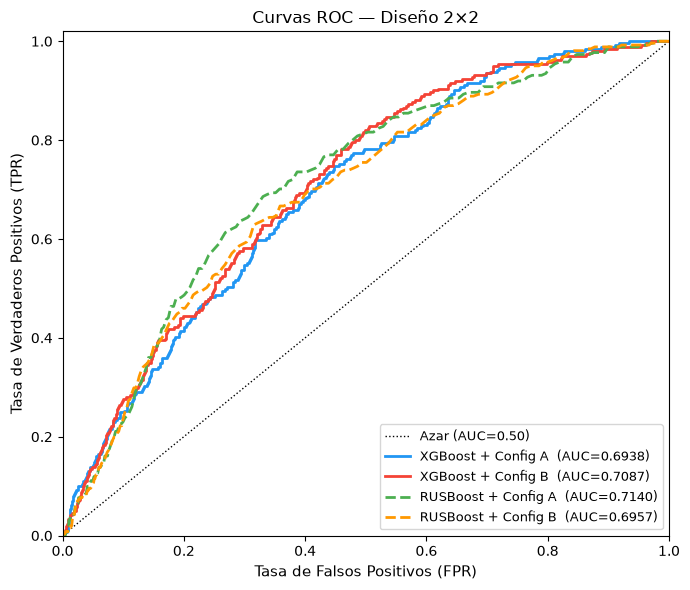

Figura guardada: ..\figures\models\roc_curves.png

Curvas Precision-Recall:


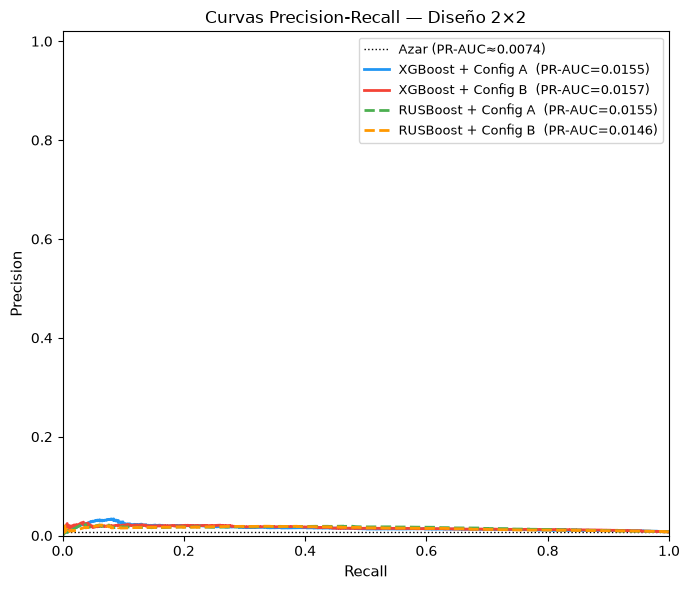

Figura guardada: ..\figures\models\pr_curves.png


In [10]:
# Diccionario de resultados para las funciones de plot
all_results = {
    "XGBoost + Config A":  res_xgb_A,
    "XGBoost + Config B":  res_xgb_B,
    "RUSBoost + Config A": res_rus_A,
    "RUSBoost + Config B": res_rus_B,
}

print("Curvas ROC:")
plot_roc_curves(all_results, FIGURES_DIR / "roc_curves.png")

print("\nCurvas Precision-Recall:")
plot_pr_curves(all_results, FIGURES_DIR / "pr_curves.png",
               prevalence=prevalence_test)

##  Interpretación inicial



In [11]:
print("=" * 65)
print("INTERPRETACIÓN FINAL —  DISEÑO 2x2")
print("=" * 65)
print()
print(f"1. CHECKPOINT BAO (Erratum 2022):")
if checkpoint_ok:
    print(f"   PASADO ✓  — RUSBoost + Config A: AUC={res_rus_A['auc']:.4f}")
    print(f"   Dentro del rango esperado [{AUC_LO}, {AUC_HI}].")
    print(f"   Confirma que el tratamiento del fraude serial es correcto.")
else:
    print(f"   FALLIDO ✗  — RUSBoost + Config A: AUC={res_rus_A['auc']:.4f}")
    print(f"   Rango esperado [{AUC_LO}, {AUC_HI}]. Revisar pipeline.")

print()
print(f"2. MEJOR MODELO:")
best_auc_label = max(all_results, key=lambda k: all_results[k]["auc"])
best_auc_val   = all_results[best_auc_label]["auc"]
print(f"   {best_auc_label}  AUC={best_auc_val:.4f}")

print()
print(f"3. IMPACTO CONFIG B (features Schilit):")
print(f"   XGBoost:   ΔAUC={delta_xgb_auc:+.4f}  ΔPR-AUC={delta_xgb_prauc:+.4f}")
print(f"   RUSBoost:  ΔAUC={delta_rus_auc:+.4f}  ΔPR-AUC={delta_rus_prauc:+.4f}")

print()
print(f"4. HIPÓTESIS H1 (ΔAUC > 0.01 en al menos un modelo):")
if h1_confirmed:
    h1_who = []
    if h1_xgb: h1_who.append(f"XGBoost (ΔAUC={delta_xgb_auc:+.4f})")
    if h1_rus: h1_who.append(f"RUSBoost (ΔAUC={delta_rus_auc:+.4f})")
    print(f"   CONFIRMADA ✓ — en: {', '.join(h1_who)}")
    print(f"   Las features Schilit añaden poder predictivo estadísticamente relevante.")
else:
    print(f"   NO CONFIRMADA — resultado nulo.")
    print(f"   Las features Schilit NO mejoran el AUC en > 0.01.")
    print(f"   Interpretación: el conjunto RAW_28 ya captura la señal.")
    print(f"   Valor científico: resultado nulo bien documentado + análisis SHAP (Día 4).")

print()
print(f"5. TABLA FINAL:")
print(f"   {'':20s} Config A (28)  Config B (38)  Delta B-A")
print(f"   {'XGBoost AUC':20s} {res_xgb_A['auc']:.4f}         {res_xgb_B['auc']:.4f}         {delta_xgb_auc:+.4f}")
print(f"   {'XGBoost PR-AUC':20s} {res_xgb_A['pr_auc']:.4f}         {res_xgb_B['pr_auc']:.4f}         {delta_xgb_prauc:+.4f}")
print(f"   {'RUSBoost AUC':20s} {res_rus_A['auc']:.4f}         {res_rus_B['auc']:.4f}         {delta_rus_auc:+.4f}")
print(f"   {'RUSBoost PR-AUC':20s} {res_rus_A['pr_auc']:.4f}         {res_rus_B['pr_auc']:.4f}         {delta_rus_prauc:+.4f}")

INTERPRETACIÓN FINAL —  DISEÑO 2x2

1. CHECKPOINT BAO (Erratum 2022):
   PASADO ✓  — RUSBoost + Config A: AUC=0.7140
   Dentro del rango esperado [0.7, 0.74].
   Confirma que el tratamiento del fraude serial es correcto.

2. MEJOR MODELO:
   RUSBoost + Config A  AUC=0.7140

3. IMPACTO CONFIG B (features Schilit):
   XGBoost:   ΔAUC=+0.0149  ΔPR-AUC=+0.0002
   RUSBoost:  ΔAUC=-0.0184  ΔPR-AUC=-0.0009

4. HIPÓTESIS H1 (ΔAUC > 0.01 en al menos un modelo):
   CONFIRMADA ✓ — en: XGBoost (ΔAUC=+0.0149)
   Las features Schilit añaden poder predictivo estadísticamente relevante.

5. TABLA FINAL:
                        Config A (28)  Config B (38)  Delta B-A
   XGBoost AUC          0.6938         0.7087         +0.0149
   XGBoost PR-AUC       0.0155         0.0157         +0.0002
   RUSBoost AUC         0.7140         0.6957         -0.0184
   RUSBoost PR-AUC      0.0155         0.0146         -0.0009
